In [1]:
import gdsfactory as gf
from ihp import PDK
from ihp.cells.capacitors import cmom
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

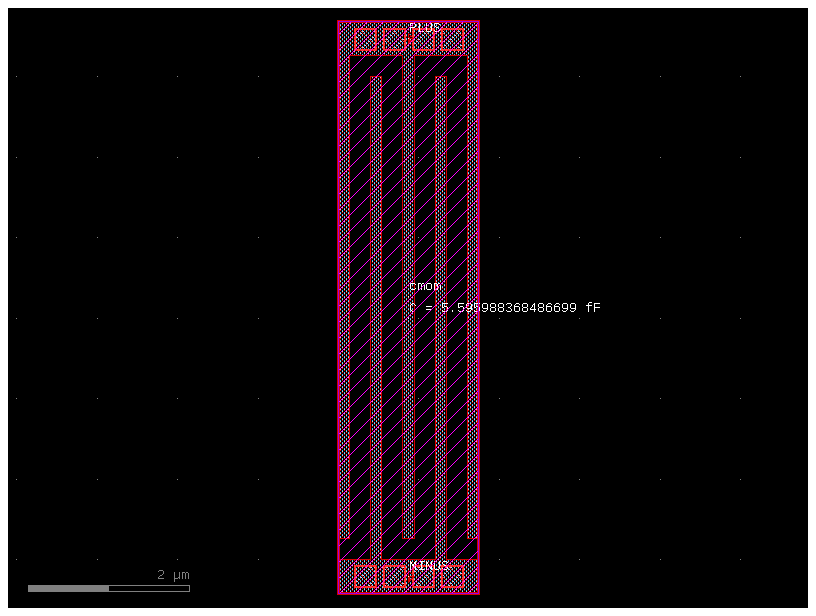

In [2]:
c = cmom(nfingers=2, length=6.0)

cc = c.copy()

cc.add_ports(c.ports)
cc.draw_ports()
cc.flatten()

cc

In [5]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-cmom")
sim.set_geometry(cc)

sim.set_stack(yaml_path=yaml_file)

sim.add_port("PLUS",from_layer="metal1",to_layer="metal3", geometry="via",impedance=50.0,excited=True)
sim.add_port("MINUS",from_layer="metal1",to_layer="metal3",geometry="via",impedance=50.0,excited=False)

sim.set_driven(fmin=1e9, fmax=20e9, num_points=21)

print(sim.validate_config())

Validation: PASSED


In [6]:
sim.mesh(preset="default")

Mesh Summary
Dimensions: 201.7 x 207.1 x 518.3 µm
Nodes:      653
Elements:   5,979
Tetrahedra: 3,653
Edge length: 0.08 - 222.71 µm
Quality:    0.327 (min: 0.000)
SICN:       0.373 (all valid)
----------------------------------------
Volumes (5):
  - air [1]
  - passive [2]
  - SiO2 [3]
  - silicon [4]
  - airbox [5]
Surfaces (9):
  - metal1_xy [6]
  - metal1_z [7]
  - metal2_xy [8]
  - metal2_z [9]
  - metal3_xy [10]
  - metal3_z [11]
  - P1 [12]
  - P2 [13]
  - Absorbing_boundary [14]
----------------------------------------
Mesh:   ../palace-sim-cmom/palace.msh

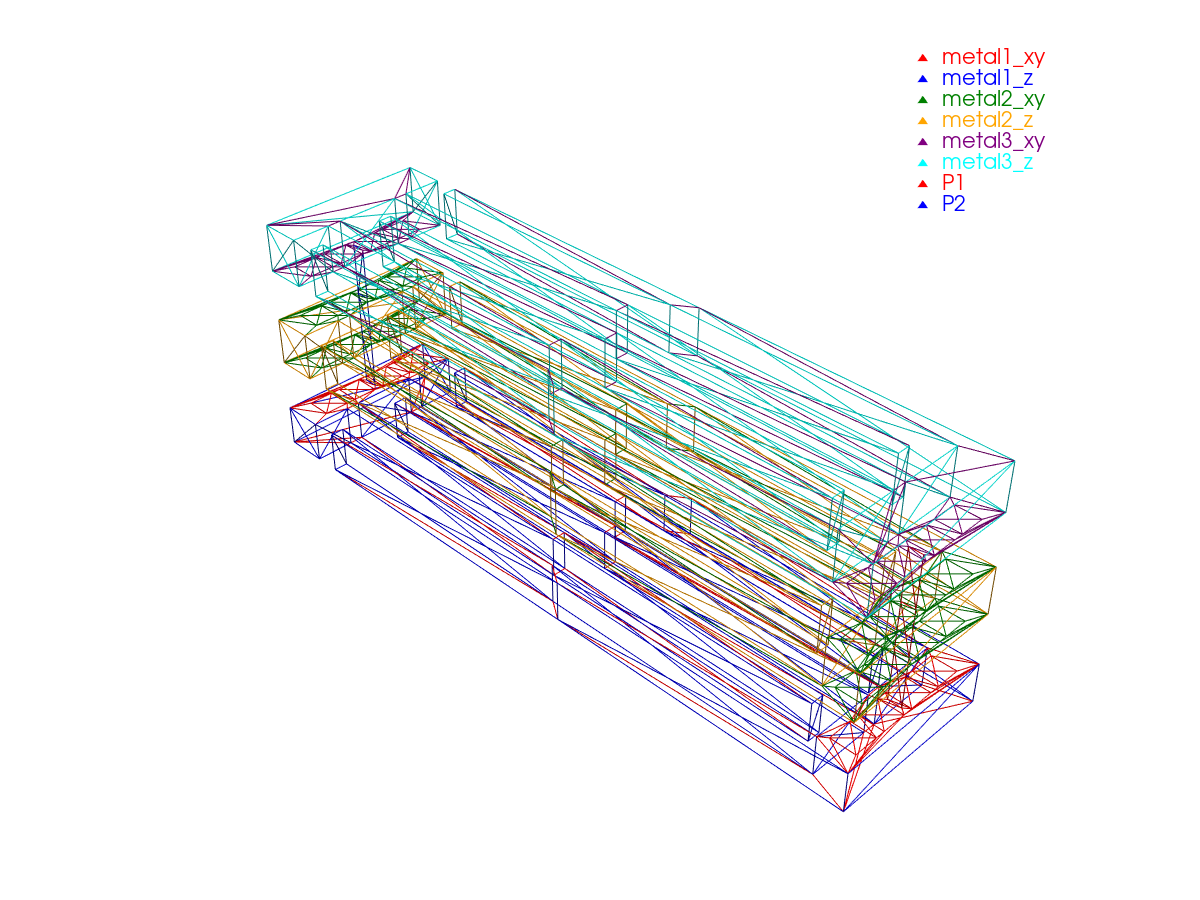

In [7]:
sim.plot_mesh(show_groups=["metal","P"], interactive=False)